# Baseline Pricing Strategies

Before applying Reinforcement Learning, it is important to establish benchmark pricing strategies.

These strategies represent simple rule-based approaches commonly used in practice.

The RL agent should consistently outperform these baselines in terms of total revenue over multiple simulated booking seasons.

## Baseline Strategies

### 1. Fixed Price Strategy

The same price is offered every day regardless of inventory or time remaining.

### 2. Time-Based Discount Strategy

Prices start high and gradually decrease as the departure date approaches, encouraging customers to purchase before the booking window closes.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [2]:
import numpy as np

In [3]:
from src.baselines import fixed_price_strategy

revenue = fixed_price_strategy()

print("Revenue:", revenue)

Revenue: 1420


In [4]:
revenues = []

for _ in range(100):
    revenues.append(fixed_price_strategy())

print("Average Revenue:", np.mean(revenues))
print("Revenue Std Dev:", np.std(revenues))
print("Minimum Revenue:", np.min(revenues))
print("Maximum Revenue:", np.max(revenues))

Average Revenue: 1336.0
Revenue Std Dev: 201.9108714259834
Minimum Revenue: 720
Maximum Revenue: 1700


## Time-Based Discount Strategy

Many industries use deterministic pricing rules instead of learning-based methods.

This strategy starts with premium prices early in the booking period and gradually lowers prices as the departure date approaches.

The goal is to maximize revenue early while improving inventory clearance near the deadline.

In [5]:
from src.baselines import time_discount_strategy

revenue = time_discount_strategy()

print("Revenue:", revenue)

Revenue: 1420


In [6]:
revenues = []

for _ in range(100):
    revenues.append(time_discount_strategy())

print("Average Revenue:", np.mean(revenues))
print("Revenue Std Dev:", np.std(revenues))
print("Minimum Revenue:", np.min(revenues))
print("Maximum Revenue:", np.max(revenues))

Average Revenue: 1090.8
Revenue Std Dev: 237.12309039821486
Minimum Revenue: 540
Maximum Revenue: 1700


## Baseline Comparison

The fixed-price strategy maintains a constant price throughout the booking season, while the time-based discount strategy adapts prices according to the remaining booking horizon.

These baseline results establish benchmark performance levels that the Reinforcement Learning agent must surpass to demonstrate successful learning.

In [7]:
fixed_results = []

discount_results = []

for _ in range(100):

    fixed_results.append(fixed_price_strategy())

    discount_results.append(time_discount_strategy())

print("========== Baseline Comparison ==========")
print(f"Fixed Price Average Revenue     : {np.mean(fixed_results):.2f}")
print(f"Time Discount Average Revenue   : {np.mean(discount_results):.2f}")

========== Baseline Comparison ==========
Fixed Price Average Revenue     : 1320.60
Time Discount Average Revenue   : 1074.00


# Q-Learning

Q-Learning is a model-free reinforcement learning algorithm that learns the expected cumulative reward for taking an action in a given state.

Instead of following predefined pricing rules, the agent gradually learns which pricing decisions maximize long-term revenue by interacting with the booking environment.

## Q-Table

The Q-table stores an estimated value for every state-action pair.

State:

(Remaining Inventory, Remaining Days)

Action:

Selected Price Level

Each table entry represents the expected cumulative revenue from taking an action in a given state and then following the learned policy.

In [8]:
from src.q_learning import QLearningAgent

agent = QLearningAgent()

print("Q-table Shape:", agent.q_table.shape)

Q-table Shape: (21, 16, 5)


## Q-Learning Hyperparameters

- **Learning Rate (α = 0.1):** Determines how quickly new experiences update existing knowledge.
- **Discount Factor (γ = 0.95):** Balances immediate rewards with future rewards.
- **Exploration Rate (ε):** Controls the trade-off between exploring new actions and exploiting learned knowledge.
- **Epsilon Decay:** Gradually reduces exploration as the agent gains experience.

In [9]:
print("Learning Rate :", agent.alpha)
print("Discount Factor :", agent.gamma)
print("Initial Epsilon :", agent.epsilon)
print("Number of Actions :", agent.env.action_space.n)

Learning Rate : 0.1
Discount Factor : 0.95
Initial Epsilon : 1.0
Number of Actions : 5


## Exploration vs Exploitation

The agent must balance two competing behaviors:

- **Exploration:** Try different pricing actions to discover better strategies.
- **Exploitation:** Choose the pricing action that currently has the highest estimated value.

This project uses an epsilon-greedy strategy to balance exploration and exploitation during training.

In [10]:
agent = QLearningAgent()

state = np.array([20, 15])

for _ in range(10):
    print(agent.choose_action(state))

2
3
0
3
2
1
2
1
4
2


In [11]:
state = np.array([20, 15])

next_state = np.array([19, 14])

action = 2

reward = 120

print("Before:", agent.q_table[20, 15, 2])

agent.update_q_table(
    state,
    action,
    reward,
    next_state,
)

print("After:", agent.q_table[20, 15, 2])

Before: 0.0
After: 12.0


In [12]:
agent = QLearningAgent()

for _ in range(10):

    print(agent.epsilon)

    agent.decay_epsilon()

1.0
0.995
0.990025
0.985074875
0.9801495006250001
0.9752487531218751
0.9703725093562657
0.9655206468094844
0.960693043575437
0.9558895783575597


# Training the Q-Learning Agent

The agent is trained by repeatedly interacting with the booking environment.

During each booking season (episode), it:

1. Observes the current state.
2. Selects a pricing action using the epsilon-greedy strategy.
3. Receives a reward based on customer purchases.
4. Updates the Q-table using the Bellman equation.
5. Gradually reduces exploration over time.

In [13]:
from src.q_learning import QLearningAgent

agent = QLearningAgent()

rewards = agent.train(episodes=500)

Episode 50/500 | Revenue = 1220 | Epsilon = 0.778
Episode 100/500 | Revenue = 1380 | Epsilon = 0.606
Episode 150/500 | Revenue = 1200 | Epsilon = 0.471
Episode 200/500 | Revenue = 1460 | Epsilon = 0.367
Episode 250/500 | Revenue = 1020 | Epsilon = 0.286
Episode 300/500 | Revenue = 1300 | Epsilon = 0.222
Episode 350/500 | Revenue = 1360 | Epsilon = 0.173
Episode 400/500 | Revenue = 940 | Epsilon = 0.135
Episode 450/500 | Revenue = 1440 | Epsilon = 0.105
Episode 500/500 | Revenue = 1300 | Epsilon = 0.082


In [14]:
print("Training Complete!")
print("Final Epsilon:", agent.epsilon)
print("Q-table Shape:", agent.q_table.shape)

Training Complete!
Final Epsilon: 0.08157186144027828
Q-table Shape: (21, 16, 5)


In [15]:
import numpy as np

np.save("../models/q_table.npy", agent.q_table)

print("Q-table saved successfully.")

Q-table saved successfully.


# Evaluating the Learned Policy

After training, the agent is evaluated without exploration.

Instead of choosing random actions, the agent always selects the pricing action with the highest learned Q-value for the current state.

The trained policy is then compared against the baseline pricing strategies to determine whether Reinforcement Learning provides better revenue performance.

In [16]:
rl_revenues = agent.evaluate(episodes=100)

print("Average Revenue:", np.mean(rl_revenues))
print("Std Revenue:", np.std(rl_revenues))
print("Minimum Revenue:", np.min(rl_revenues))
print("Maximum Revenue:", np.max(rl_revenues))

Average Revenue: 1209.6
Std Revenue: 183.85820623513112
Minimum Revenue: 580
Maximum Revenue: 1620


In [17]:
fixed_results = []
discount_results = []

for _ in range(100):

    fixed_results.append(fixed_price_strategy())

    discount_results.append(time_discount_strategy())

print("========== Final Comparison ==========")
print(f"Fixed Price Strategy Average Revenue : {np.mean(fixed_results):.2f}")
print(f"Time Discount Strategy Average Revenue : {np.mean(discount_results):.2f}")
print(f"Q-Learning Average Revenue : {np.mean(rl_revenues):.2f}")

========== Final Comparison ==========
Fixed Price Strategy Average Revenue : 1326.20
Time Discount Strategy Average Revenue : 1052.20
Q-Learning Average Revenue : 1209.60


## Evaluation Summary

The trained Q-Learning agent is evaluated over multiple simulated booking seasons and compared with two rule-based pricing strategies.

A higher average revenue indicates that the reinforcement learning agent has learned a more effective pricing policy.

The comparison demonstrates whether learning from interaction with the environment provides measurable improvements over traditional heuristic approaches.

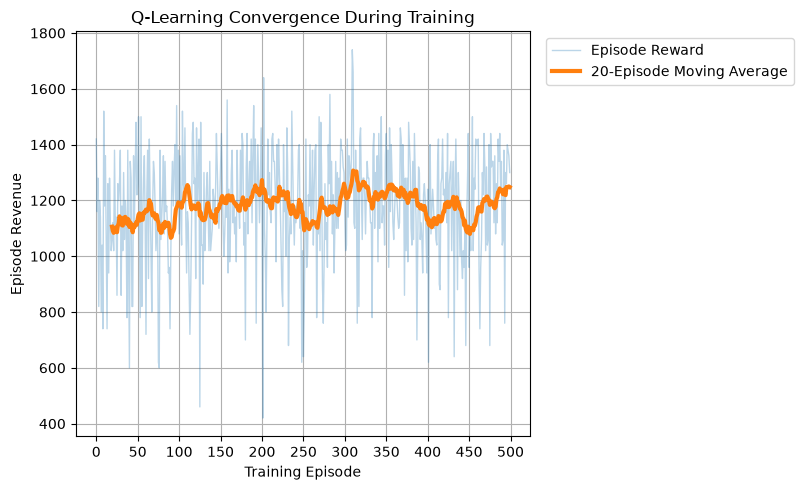

In [18]:
import numpy as np
import matplotlib.pyplot as plt

window = 20

moving_avg = np.convolve(rewards, np.ones(window) / window, mode="valid")

plt.figure(figsize=(10, 5))

plt.plot(rewards, alpha=0.3, linewidth=1, label="Episode Reward")

plt.plot(
    range(window - 1, len(rewards)),
    moving_avg,
    linewidth=3,
    label="20-Episode Moving Average",
)

plt.title("Q-Learning Convergence During Training")
plt.xlabel("Training Episode")
plt.ylabel("Episode Revenue")
plt.xticks(np.arange(0, 501, 50))
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=True)
plt.grid(True)

plt.tight_layout(rect=[0, 0, 0.82, 1])

plt.savefig("../outputs/figures/q_learning_training.png", dpi=300, bbox_inches="tight")

plt.show()